# Word2Vec — Skip-gram + Negative Sampling (Pure NumPy)

Trained on WikiText-2.  
Implementation follows the original `word2vec.c` by Mikolov et al.

**References:**
- Mikolov et al., *Efficient Estimation of Word Representations in Vector Space* (2013)
- Mikolov et al., *Distributed Representations of Words and Phrases and their Compositionality* (2013)
- [Original C implementation](https://github.com/tmikolov/word2vec/blob/master/word2vec.c)

## 1. Hyperparameters

In [31]:
EMBEDDING_DIM = 100
MIN_COUNT = 5
EPOCHS = 5
LR_START = 0.025
LR_MIN = 0.0001
WINDOW_SIZE = 5
NEG_SAMPLES = 5
SUBSAMPLE_THRESHOLD = 1e-3

TXT_PATH = "data/wikitext-2-v1.txt"  # adjust path if needed

## 2. Data preprocessing

In [32]:
import numpy as np
import re
from collections import Counter

np.random.seed(33)

def clean_text(raw_text):
    text = raw_text.lower()
    text = text.replace("<unk>", " ")
    text = re.sub(r"^=.*$", "", text, flags=re.MULTILINE)
    text = re.sub(r"[^a-z]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

def build_vocab(tokens, min_count):
    counts = Counter(tokens)
    vocab = {w: c for w, c in counts.items() if c >= min_count}
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return vocab, word2idx, idx2word

def make_neg_table(vocab, word2idx, table_size=1_000_000, power=0.75):
    freqs = np.array([vocab[w] for w in word2idx])
    freqs = freqs ** power
    freqs_norm = freqs / freqs.sum()
    cumul = np.cumsum(freqs_norm)
    positions = np.arange(table_size) / table_size
    table = np.searchsorted(cumul, positions).astype(np.int32)
    return table

def subsample_tokens(tokens, vocab, word2idx, threshold=1e-3):
    indices = np.array([word2idx[t] for t in tokens if t in word2idx])
    counts = np.array([vocab[t] for t in tokens if t in word2idx])
    total = sum(vocab.values())
    freqs_norm = counts / total
    keep_prob = (np.sqrt(freqs_norm / threshold) + 1) * (threshold/ freqs_norm)
    mask = np.random.random(len(indices)) < keep_prob
    return indices[mask]

## 3. Model

In [33]:
class Word2Vec:
    def __init__(self, vocab_size, embedding_dim=100):
        scale = 0.5 / embedding_dim
        self.W_center = np.random.uniform(-scale, scale,(vocab_size, embedding_dim))
        self.W_context = np.zeros((vocab_size, embedding_dim))

    def sigmoid(self, z):
        z = np.clip(z, -6, 6)
        return 1 / (1 + np.exp(-z))

    def train_pair(self, center_idx, context_idx, neg_indices, lr):
        center = self.W_center[center_idx]
        context_pos = self.W_context[context_idx]
        context_neg = self.W_context[neg_indices]

        score_pos = np.dot(center, context_pos)
        error_pos = self.sigmoid(score_pos) - 1

        score_neg = context_neg @ center
        error_neg = self.sigmoid(score_neg)

        grad_center = error_pos * context_pos + (error_neg[:,None] * context_neg).sum(axis=0)

        self.W_context[context_idx] -= lr * (error_pos * center)
        for k in range(len(neg_indices)):
            self.W_context[neg_indices[k]] -= lr * (error_neg[k] * center)
        self.W_center[center_idx] -= lr * grad_center

        loss = -np.log(self.sigmoid(score_pos) + 1e-7) - np.log(self.sigmoid(-score_neg) +1e-7).sum()
        return loss

## 4. Training loop

In [34]:
import time
import sys

def generate_training_data(token_ids, window_size):
    n = len(token_ids)
    for i in range(n):
        w = np.random.randint(1, window_size + 1)
        start = max(0, i - w)
        end = min(n, i + w + 1)
        center = token_ids[i]
        contexts = []
        for j in range(start, end):
            if j != i:
                contexts.append(token_ids[j])
        yield center, contexts


def train(model, token_ids, neg_table, epochs, lr_start, lr_min,
          window_size, neg_samples):
    losses = []
    word_count = 0
    total_words = len(token_ids) * epochs

    for epoch in range(epochs):
        epoch_loss = 0
        pair_in_epoch = 0
        start_time = time.time()

        for center, contexts in generate_training_data(token_ids, window_size):

            lr = max(lr_start * (1 - word_count / total_words), lr_min)
            word_count += 1
            for context in contexts:
                neg_indices = neg_table[np.random.randint(0, len(neg_table), neg_samples)]
                loss = model.train_pair(center, context, neg_indices, lr)
                epoch_loss += loss
                pair_in_epoch += 1

            if word_count % 100000 == 0:
                elapsed = time.time() - start_time
                print(f"\r  Epoch {epoch + 1}: {word_count:,} words  "
                      f"loss: {epoch_loss / max(pair_in_epoch, 1):.4f}  "
                      f"lr: {lr:.6f}  {elapsed:.0f}s", end="")

        avg_loss = epoch_loss / max(pair_in_epoch, 1)
        losses.append(avg_loss)
        elapsed = time.time() - start_time
        print(f"\rEpoch {epoch + 1}/{epochs}  loss: {avg_loss:.4f} "
              f" lr: {lr:.6f}  {elapsed:.0f}s\033[K")
        sys.stdout.flush()
    return losses

## 5. Run training

In [35]:
with open(TXT_PATH, "r", encoding="utf-8") as f:
    text = f.read()

tokens = clean_text(text)
vocab, word2idx, idx2word = build_vocab(tokens, min_count=MIN_COUNT)
print(f"Vocab size: {len(vocab)}")

neg_table = make_neg_table(vocab, word2idx)
token_ids = subsample_tokens(tokens, vocab, word2idx, threshold=SUBSAMPLE_THRESHOLD)
print(f"Tokens after subsampling: {len(token_ids)}")

model = Word2Vec(len(vocab), embedding_dim=EMBEDDING_DIM)
losses = train(model, token_ids, neg_table,
               epochs=EPOCHS,
               lr_start=LR_START,
               lr_min=LR_MIN,
               window_size=WINDOW_SIZE,
               neg_samples=NEG_SAMPLES)

np.save("embeddings.npy", model.W_center)
np.save("vocab.npy", np.array(list(word2idx.keys())))
np.save("vocab_counts.npy", np.array([vocab[w] for w in word2idx]))
np.save("losses.npy", np.array(losses))
print(f"Done. Saved embeddings.npy, vocab.npy, vocab_counts.npy, losses.npy")

Vocab size: 19381
Tokens after subsampling: 1189655
Epoch 1/5  loss: 2.4745  lr: 0.020000  412s0.020377  381s
Epoch 2/5  loss: 2.3120  lr: 0.015000  409s0.015333  382s
Epoch 3/5  loss: 2.2949  lr: 0.010000  409s0.010290  385s
Epoch 4/5  loss: 2.3038  lr: 0.005000  409s0.005246  388s
Epoch 5/5  loss: 2.3412  lr: 0.000100  409s0.000203  392s
Done. Saved embeddings.npy, vocab.npy, vocab_counts.npy, losses.npy


## 6. Evaluation

In [36]:
import matplotlib.pyplot as plt

# If loading from files (comment out if just trained above):
# embeddings = np.load("embeddings.npy")
# vocab = np.load("vocab.npy", allow_pickle=True)
# vocab_counts = np.load("vocab_counts.npy")
# losses = np.load("losses.npy")
# word2idx = {w: i for i, w in enumerate(vocab)}
# idx2word = {i: w for w, i in word2idx.items()}

# If just trained, use directly:
embeddings = model.W_center
vocab_counts = np.array([vocab[w] for w in word2idx])

print(f"Vocab: {len(word2idx)}, Embedding dim: {embeddings.shape[1]}")
print(f"vocab_counts shape: {vocab_counts.shape}")

Vocab: 19381, Embedding dim: 100
vocab_counts shape: (19381,)


In [37]:
# helpers
def check_word(word):
    if word not in word2idx:
        print(f"Warning: Word '{word}' not found in vocabulary.")
        return 1
    return 0

def show_sim(search_list):
    for word in search_list:
        print(f"\n{word}:")
        for w, s in most_similar(word, top_n=5):
            print(f"  {w:20s} {s:.4f}")

def show_analogy(tests, top_n=5):
    for test in tests:
        a, b, c = test
        print(f"\n{a} - {b} + {c} =")
        for item in analogy(a, b, c, top_n):
            print(f"  {item[0]:20s} {item[1]:.4f}")

### Nearest neighbours (cosine similarity)

In [38]:
def most_similar(word, top_n=10):
    if check_word(word):
        return []

    idx = word2idx[word]
    vec = embeddings[idx]
    norms = np.linalg.norm(embeddings, axis=1) * np.linalg.norm(vec)
    sims = embeddings @ vec / (norms + 1e-7)
    best = np.argsort(sims)[::-1][1:top_n+1]
    return [(idx2word[i], round(float(sims[i]), 4)) for i in best]


tests = ["king", "computer", "history", "mother", "money"]
show_sim(tests)


king:
  leinster             0.7768
  henry                0.7402
  odaenathus           0.7294
  lord                 0.7277
  throne               0.7172

computer:
  graphics             0.8274
  dota                 0.8230
  gaming               0.8222
  user                 0.8182
  multiplayer          0.8127

history:
  geography            0.6776
  origins              0.6764
  today                0.6710
  eighteenth           0.6651
  esports              0.6628

mother:
  husband              0.8744
  daughter             0.8562
  father               0.8546
  wife                 0.8378
  judith               0.8173

money:
  pay                  0.8022
  paying               0.7770
  raise                0.7757
  opportunity          0.7750
  offer                0.7739


### Word analogies

In [39]:
def analogy(a, b, c, top_n=5):
  """a to b as c to ... """
  if sum([check_word(word) for word in [a,b,c]]):
    return []
  vec = embeddings[word2idx[a]] - embeddings[word2idx[b]] + embeddings[word2idx[c]]
  norms = np.linalg.norm(embeddings, axis=1) * np.linalg.norm(vec)
  sims = embeddings @ vec / (norms + 1e-7)

  for w in [a,b,c]:
    sims[word2idx[w]] = -1
  best = np.argsort(sims)[::-1][:top_n]
  return [(idx2word[i], round(float(sims[i]), 4)) for i in best]


tests = [
    ("king", "man", "woman"),
    ("germany", "berlin", "london"),
    ("germany", "beer", "tea"),
    ("hockey", "ice", "grass"),
    ("poet", "novel", "music"),
]
show_analogy(tests)


king - man + woman =
  leinster             0.6924
  throne               0.6856
  hairan               0.6768
  odaenathus           0.6697
  mar                  0.6643

germany - berlin + london =
  netherlands          0.7980
  italy                0.7865
  sweden               0.7759
  switzerland          0.7687
  finland              0.7487

germany - beer + tea =
  russia               0.8337
  czech                0.8044
  venezuela            0.8028
  naples               0.8007
  servicemen           0.8007

hockey - ice + grass =
  sports               0.8315
  collegiate           0.8041
  athletics            0.7974
  golf                 0.7908
  paralympic           0.7877

poet - novel + music =
  jazz                 0.6823
  musicians            0.6632
  pop                  0.6570
  christian            0.6566
  singers              0.6536


### Training loss

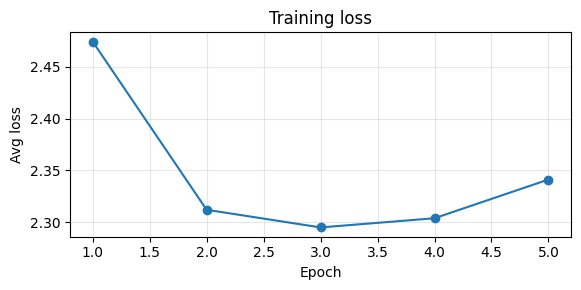

In [40]:
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(losses) + 1), losses, "o-")
plt.xlabel("Epoch")
plt.ylabel("Avg loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### t-SNE visualisation

top_vecs shape: (200, 100)


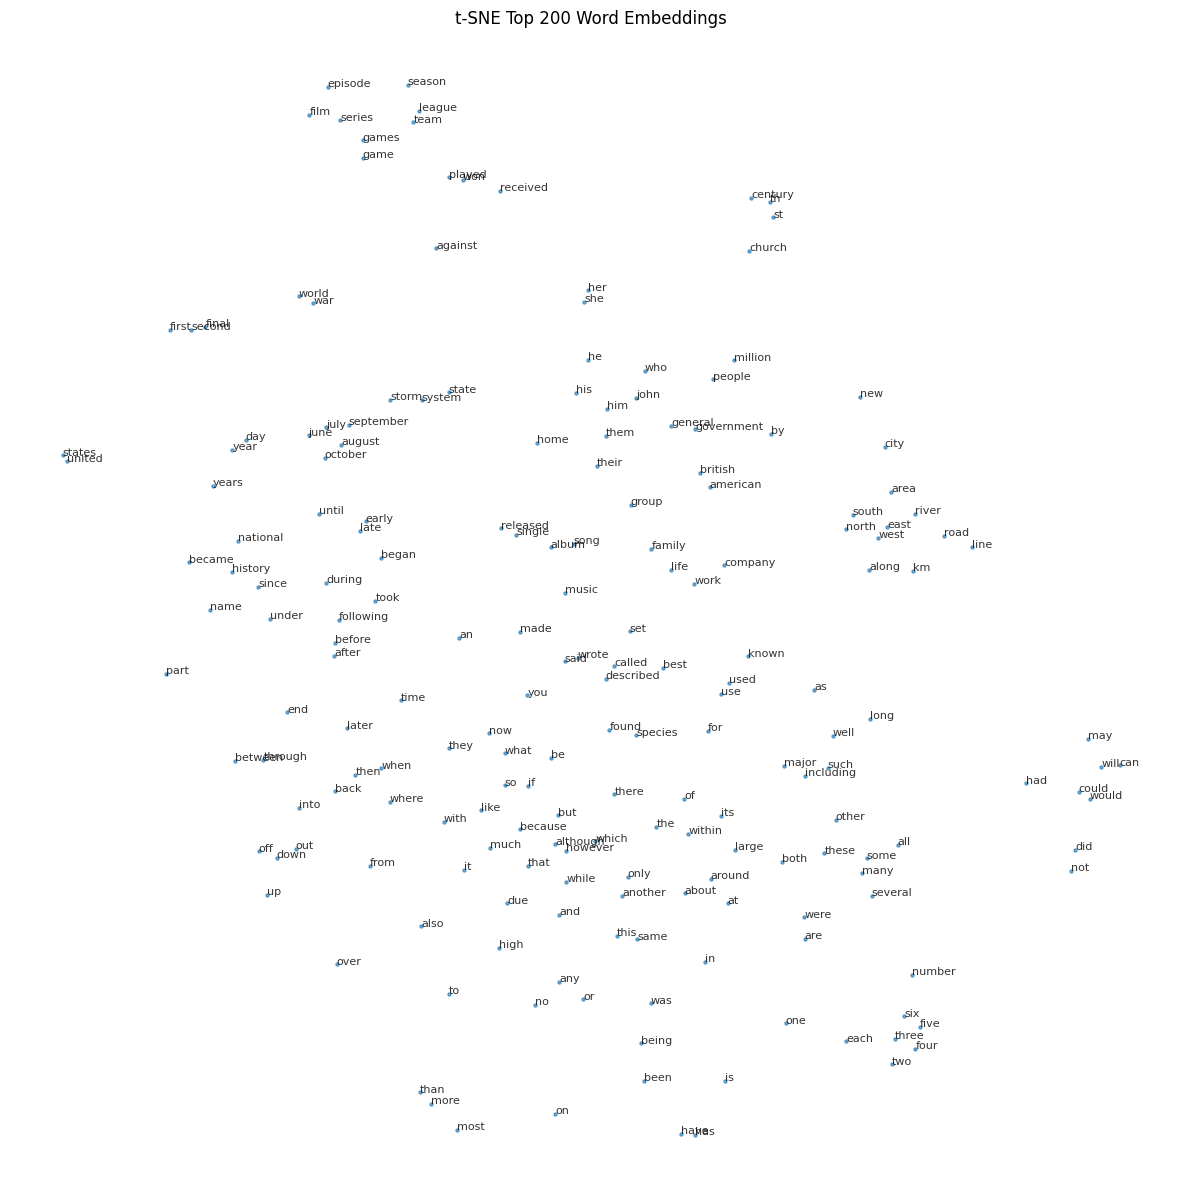

In [55]:
from sklearn.manifold import TSNE


top_k = 200
top_indices = np.argsort(vocab_counts)[::-1][:top_k]
top_words = [idx2word[i]  for i in top_indices]
top_vecs = embeddings[top_indices]

print(f"top_vecs shape: {top_vecs.shape}")

tsne = TSNE(n_components=2,  random_state=42, perplexity=10, max_iter=1000)
vecs_2d_tsne = tsne.fit_transform(top_vecs)

plt.figure(figsize=(15, 15))
plt.scatter(vecs_2d_tsne[:, 0], vecs_2d_tsne[:, 1], s=5, alpha=0.6)
for i, w in enumerate(top_words):
    plt.annotate(w, (vecs_2d_tsne[i, 0], vecs_2d_tsne[i, 1]), fontsize=8, alpha=0.8)
plt.title(f"t-SNE Top {top_k} Word Embeddings")
plt.axis("off")
plt.show()

### PCA visualisation

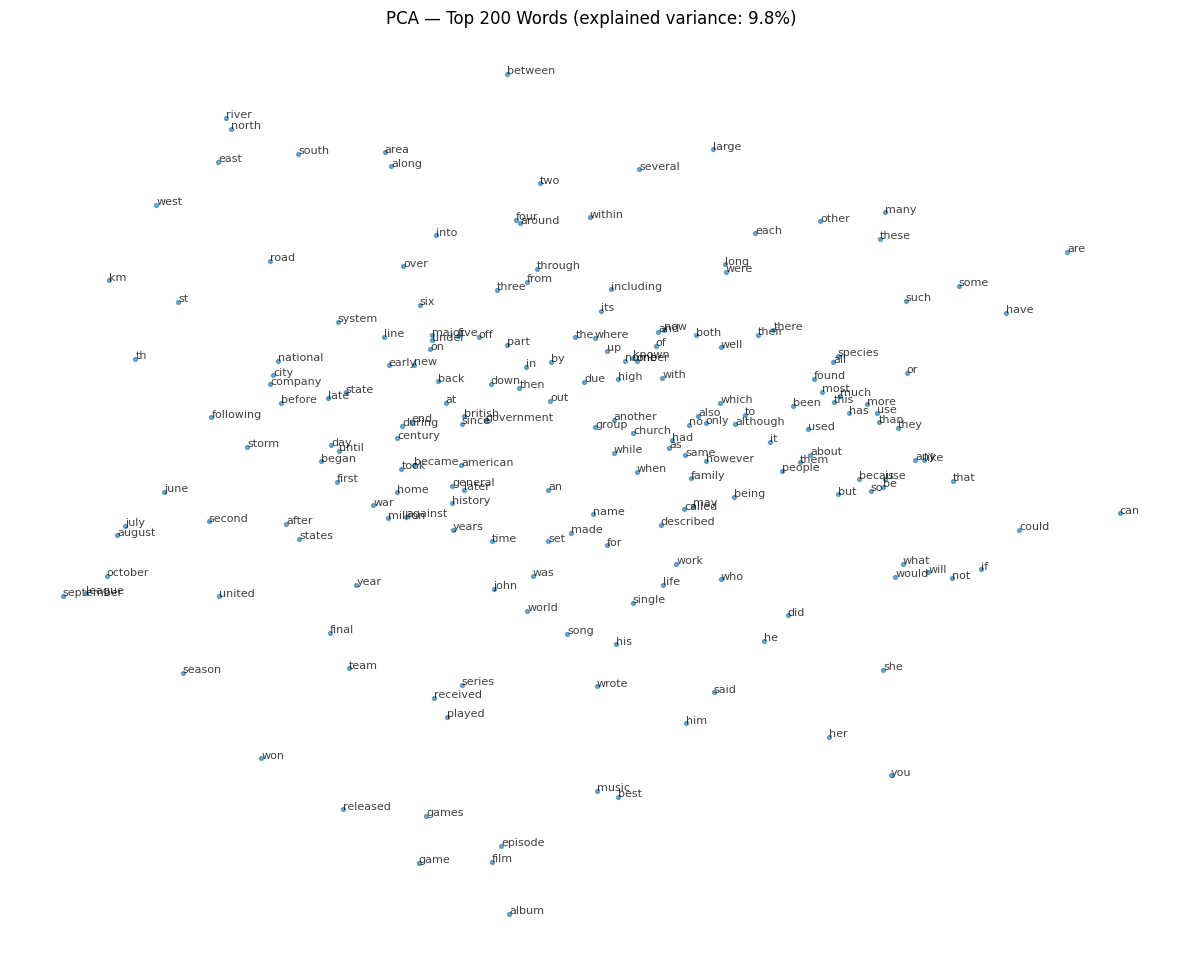

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
vecs_2d_pca = pca.fit_transform(top_vecs)

plt.figure(figsize=(15, 12))
plt.scatter(vecs_2d_pca[:, 0], vecs_2d_pca[:, 1], s=8, alpha=0.6)
for i, w in enumerate(top_words):
    plt.annotate(w, (vecs_2d_pca[i, 0], vecs_2d_pca[i, 1]), fontsize=8, alpha=0.75)
plt.title(f"PCA — Top {top_k} Words (explained variance: {pca.explained_variance_ratio_.sum():.1%})")
plt.axis("off")
plt.show()

## Save to Google Drive (optional)

In [43]:
# import numpy as np
#
# np.save("embeddings.npy", model.W_center)
# np.save("vocab.npy", np.array(list(word2idx.keys())))
# np.save("vocab_counts.npy", np.array([vocab[w] for w in word2idx]))
# np.save("losses.npy", np.array(losses))
#
# from google.colab import drive
# drive.mount('/content/drive')
#
# import shutil, os
# dst = "/content/drive/MyDrive/JB_apply"
# os.makedirs(dst, exist_ok=True)
#
# for f in ["embeddings.npy", "vocab.npy", "vocab_counts.npy", "losses.npy"]:
#     shutil.copy(f, dst)
#     print(f"Copied {f} → {dst}/")
#
# print(f"\nDone! losses: {losses}")

In [44]:
# from google.colab import drive
# drive.mount('/content/drive')